# **Player Feedback Analysis in Video Games**

This script:
- Cleans data
- Applies log transformations
- Creates Visuals
- Runs regression models

In [1]:
import pandas as pd
import numpy as np
import statistics
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

In [ ]:
data_path = "./PATH"
df = pd.read_csv(data_path)

pd.set_option('display.max_rows', 5)
df.head()

,AppID,Name,Release date,Estimated owners,Peak CCU,Required age,Price,Discount,DLC count,About the game,...,Average playtime two weeks,Median playtime forever,Median playtime two weeks,Developers,Publishers,Categories,Genres,Tags,Screenshots,Movies
0,2539430,Black Dragon Mage Playtest,"Aug 1, 2023",0 - 0,0,0,0.00,0,0,NaN,...,0,0,0,NaN,NaN,NaN,NaN,NaN,https://shared.akamai.steamstatic.com/store_it...,NaN
1,496350,Supipara - Chapter 1 Spring Has Come!,"Jul 29, 2016",0 - 20000,0,0,5.24,65,0,"Springtime, April: when the cherry trees come ...",...,0,8,0,minori,MangaGamer,"Single-player,Steam Trading Cards,Steam Cloud,...",Adventure,"Adventure,Visual Novel,Anime,Cute",https://shared.akamai.steamstatic.com/store_it...,NaN
2,1034400,Mystery Solitaire The Black Raven,"May 6, 2019",0 - 20000,0,0,4.99,0,0,"Immerse yourself in the most beloved, mystical...",...,0,0,0,Somer Games,8floor,"Single-player,Family Sharing",Casual,"Casual,Card Game,Solitaire,Puzzle,Hidden Objec...",https://shared.akamai.steamstatic.com/store_it...,NaN
3,3292190,버튜버 파라노이아 - Vtuber Paranoia,"Oct 31, 2024",0 - 20000,1,0,8.99,0,1,"synopsis 'Hello, I'm Hiyoro, a new YouTuber!' ...",...,0,0,0,유진게임즈,유진게임즈,"Single-player,Steam Achievements,Family Sharing","Casual,Indie,Simulation",NaN,https://shared.akamai.steamstatic.com/store_it...,NaN
4,3631080,Maze Quest VR,"Apr 24, 2025",0 - 20000,0,0,4.99,0,0,Its not just a Maze; its a Quest! Enter the ca...,...,0,0,0,Reality Expanded LLC,Reality Expanded LLC,"Single-player,VR Only,Steam Leaderboards,Famil...","Action,Early Access",NaN,https://shared.akamai.steamstatic.com/store_it...,NaN


In [ ]:
print(f"Shape:\n   {df.shape}")

Veriset'in Şekli:
   (122611, 40)


In [ ]:
columns = df.columns
types = df.dtypes
typecolumn = {'Coloumn' : columns, 'Type' : types}

var_type = pd.DataFrame(typecolumn)
var_type

,Sutun,Tur
AppID,AppID,int64
Name,Name,str
...,...,...
Screenshots,Screenshots,str
Movies,Movies,float64


## Data Cleaning and Featre engineering

Real Price

In [ ]:
df['Real_price'] = df['Price']

mask = df['Price'] > 0
df.loc[mask, 'Real_price'] = round(
    df.loc[mask, 'Price'] * (1 + df.loc[mask, 'Discount']/100), 2
)

Release year

In [6]:
df.rename(columns = {'Release date' : 'Release_date'} , inplace = True)
df['Release_date'] = pd.to_datetime(df['Release_date'], errors = 'coerce')
df['Release_year'] = df['Release_date'].dt.year

log1p on skewed variables

In [7]:
df['log_achievements'] = np.log1p(df['Achievements'])
df['log_med_playtime_forever'] = np.log1p(df['Median playtime forever'])
df['log_positive'] = np.log1p(df['Positive'])

One hot encoding the top 10 genres

In [ ]:


df['Genres'] = df['Genres'].fillna('')
genre_counts = df['Genres'].str.split(',').explode().value_counts()
sorted_genres = genre_counts.index.tolist()
sorted_genres



top_genres = sorted_genres[0 : 12]
genres_oneshot = df['Genres'].str.get_dummies(sep = ',')
genres_oneshot = genres_oneshot.reindex(columns = top_genres, fill_value = 0)
df = df.join(genres_oneshot)

1. Limiting the Price range
2. Removing games with no players

In [9]:
mask = (df['Real_price'] > 100) | (df['Estimated owners'] == '0 - 0')
print(f'{mask.sum()} rows removed. (Games above 100$)' )
df = df[~mask]

21837 rows removed. (Games above 100$)


3. Cleaning duplicates

In [10]:
mapping = {
    '0 - 0': 0,
    '0 - 20000': 1,
    '20000 - 50000': 2,
    '50000 - 100000': 3,
    '100000 - 200000': 4,
    '200000 - 500000': 5,
    '500000 - 1000000': 6,
    '1000000 - 2000000': 7,
    '2000000 - 5000000': 8,
    '5000000 - 10000000': 9,
    '10000000 - 20000000': 10,
    '20000000 - 50000000': 11,
    '50000000 - 100000000': 12,
    '100000000 - 200000000': 13
}

df['owner_ord'] = df['Estimated owners'].map(mapping)

In [11]:
duplicates = df[df.duplicated('Name')]

df = df.sort_values('owner_ord', ascending = False)
df = df.drop_duplicates(subset = 'Name', keep = 'first')
df

,AppID,Name,Release_date,Estimated owners,Peak CCU,Required age,Price,Discount,DLC count,About the game,...,Adventure,Simulation,Strategy,RPG,Free To Play,Early Access,,Sports,Racing,owner_ord
8878,578080,PUBG: BATTLEGROUNDS,2017-12-21,100000000 - 200000000,314682,13,0.00,0,0,LAND Drop into an ever-growing and changin...,...,1,0,0,0,1,0,0,0,0,13
4193,570,Dota 2,2013-07-09,100000000 - 200000000,623941,0,0.00,0,2,"The most-played game on Steam. Every day, mill...",...,0,0,1,0,1,0,0,0,0,13
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23,2072070,RPG Plus - Virtual Tabletop,2024-02-14,0 - 20000,0,0,0.00,0,0,RPG Plus is the all-in-one solution for Tablet...,...,0,0,1,1,0,0,0,0,0,1
22,815170,Zombie World,2018-06-01,0 - 20000,0,0,7.99,0,0,"Zombie world A dead city occupied by zombies, ...",...,1,0,0,1,0,0,0,0,0,1


## Choosing variables

In [ ]:
data = df[[
    'Name', 'log_med_playtime_forever', 'Release_year', 
    'log_achievements', 'Real_price',
    'Indie', 'Casual', 'Action', 'Adventure', 
    'Simulation', 'Strategy', 'RPG',
    'Early Access', 'Sports', 'Racing',
    'log_positive'
]
]

data.set_index('Name', inplace = True)
data.head()

,log_med_playtime_forever,Release_year,log_achievements,Real_price,Indie,Casual,Action,Adventure,Simulation,Strategy,RPG,Early Access,Sports,Racing,log_positive
Name,,,,,,,,,,,,,,,
PUBG: BATTLEGROUNDS,8.713253,2017,3.637586,0.00,0,0,1,1,0,0,0,0,0,0,14.234522
Dota 2,7.052721,2013,0.000000,0.00,0,0,1,0,0,1,0,0,0,0,14.527059
Apex Legends™,6.821107,2020,2.564949,0.00,0,0,1,1,0,0,0,0,0,0,13.412124
Counter-Strike 2,8.738415,2012,0.693147,0.00,0,0,1,0,0,0,0,0,0,0,15.849181
Left 4 Dead 2,6.293419,2009,4.624973,1.99,0,0,1,0,0,0,0,0,0,0,13.753871


Descriptive Statistics

In [13]:
# Calc func 

def math_calc (data):
    data_desc_stats = data.agg(['mean', 'median', 'std', 'var', 'skew', 'kurt'])
    mode_vals = data.mode().iloc[0]
    data_desc_stats.loc['mode'] = mode_vals
    
    return data_desc_stats


def corr_matrix(data):
    corr_mtrx = data.corr(method = 'pearson')
    return corr_mtrx

In [ ]:
data_desc = math_calc(data)
data_desc

,log_med_playtime_forever,Release_year,log_achievements,Real_price,Indie,Casual,Action,Adventure,Simulation,Strategy,RPG,Early Access,Sports,Racing,log_positive
mean,1.335757,2021.033194,1.671842,5.733370,0.710499,0.431955,0.408348,0.399301,0.210464,0.195723,0.183674,0.096550,0.042421,0.035486,2.756185
median,0.000000,2022.000000,1.945910,3.740000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.397895
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
kurt,0.363170,0.901646,-1.174912,23.453317,-1.138319,-1.924557,-1.860959,-1.830930,0.018042,0.352695,0.669521,5.464478,18.618540,23.218216,0.672190
mode,0.000000,2024.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [ ]:
data_corr = corr_matrix(data)
data_corr

,log_med_playtime_forever,Release_year,log_achievements,Real_price,Indie,Casual,Action,Adventure,Simulation,Strategy,RPG,Early Access,Sports,Racing,log_positive
log_med_playtime_forever,1.000000,-0.347288,0.288971,0.211588,-0.074413,-0.123480,0.004778,0.023137,0.062129,0.057345,0.087902,-0.051269,-0.000459,-0.010276,0.655798
Release_year,-0.347288,1.000000,-0.001167,0.104814,0.039953,0.074044,-0.031980,0.038552,0.054853,0.000779,0.041823,0.062415,-0.012956,-0.002124,-0.423647
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Racing,-0.010276,-0.002124,-0.018158,0.003140,-0.011501,0.014446,0.035215,-0.056872,0.076526,-0.042405,-0.056200,0.016233,0.258072,1.000000,0.000072
log_positive,0.655798,-0.423647,0.311270,0.122267,-0.034749,-0.153415,0.050830,0.048332,0.030403,0.037382,0.059201,-0.064316,0.001360,0.000072,1.000000


## Plots

In [ ]:
path = r'.\Plots'

def heatmap(data, title, figsize = (12, 8), cmap = 'coolwarm', center = 0, annot = True ):
    plt.figure(figsize= figsize)
    sns.heatmap(data = data, cmap= cmap, 
                center = center, annot= annot, fmt= '.2f')
    plt.title(title)
    plt.savefig(f'{path}\{title}.png'
            ,dpi = 300, bbox_inches = 'tight' )
    plt.show()

def group_hist(data, col, title, figsize = (12, 8), bins = 30, color = 'purple', edgecolor = 'black'):
        plt.figure(figsize=(12,8))
        plt.hist(data[col], bins = bins, 
                alpha = 1, color = color, edgecolor = edgecolor)
        plt.title(title)
        plt.xlabel(col)
        plt.ylabel('Count')
        plt.savefig(f'{path}\{title}.png'
            ,dpi = 300, bbox_inches = 'tight' )
        plt.show()

def reg_scatter(data, title, x, y, figsize = (12, 8)):
      plt.figure(figsize = figsize)
      sns.regplot(data = data, x = x, y = y)
      plt.title(title)
      plt.savefig(f'{path}\{title}.png'
            ,dpi = 300, bbox_inches = 'tight' )
      plt.show()

def boxplot(data, title, x, y, figsize = (12, 8)):
      plt.figure(figsize = figsize)
      sns.boxenplot(data = data, x = x, y = y)
      plt.title(title)
      plt.savefig(f'{path}\{title}.png'
            ,dpi = 300, bbox_inches = 'tight' )
      plt.show()

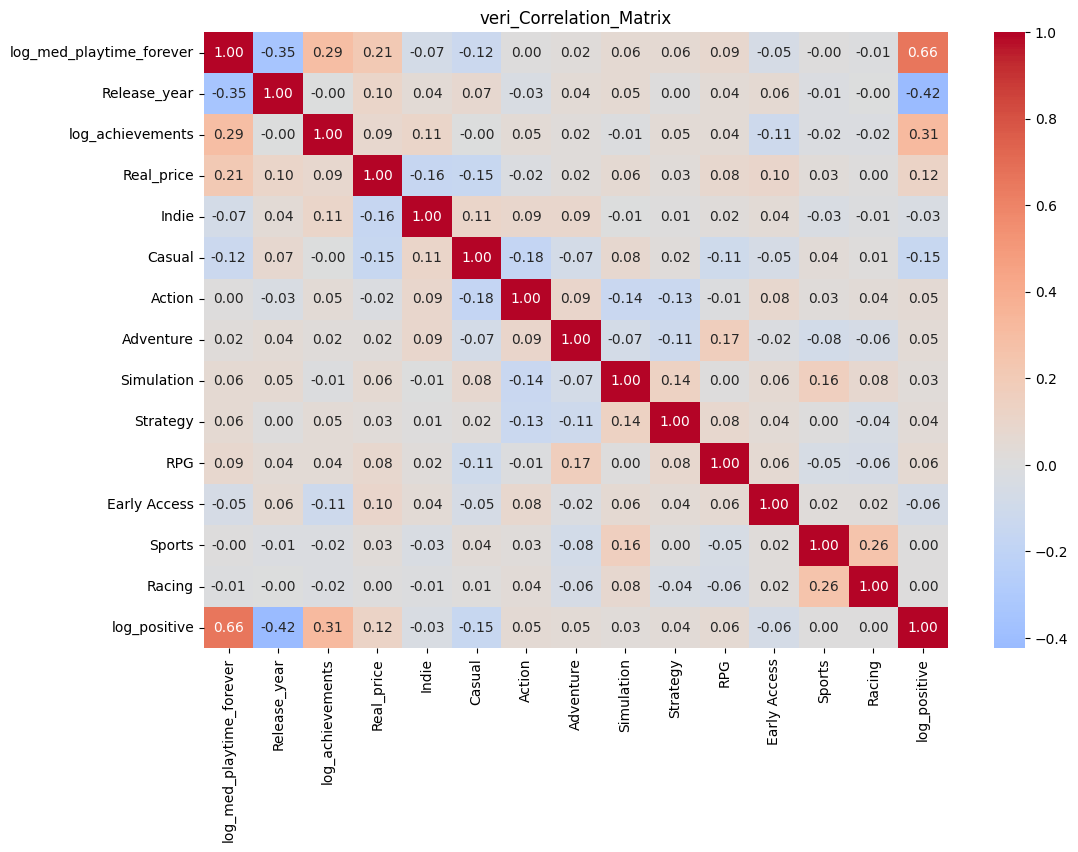

In [ ]:
heatmap(data_corr, 'data_Correlation_Matrix')

In [ ]:
data_catcols = [
    'Indie', 'Casual', 'Action', 'Adventure', 
    'Simulation', 'Strategy', 'RPG',
    'Early Access', 'Sports', 'Racing'
]
data_numcols = [col for col in data.columns if col not in data_catcols]

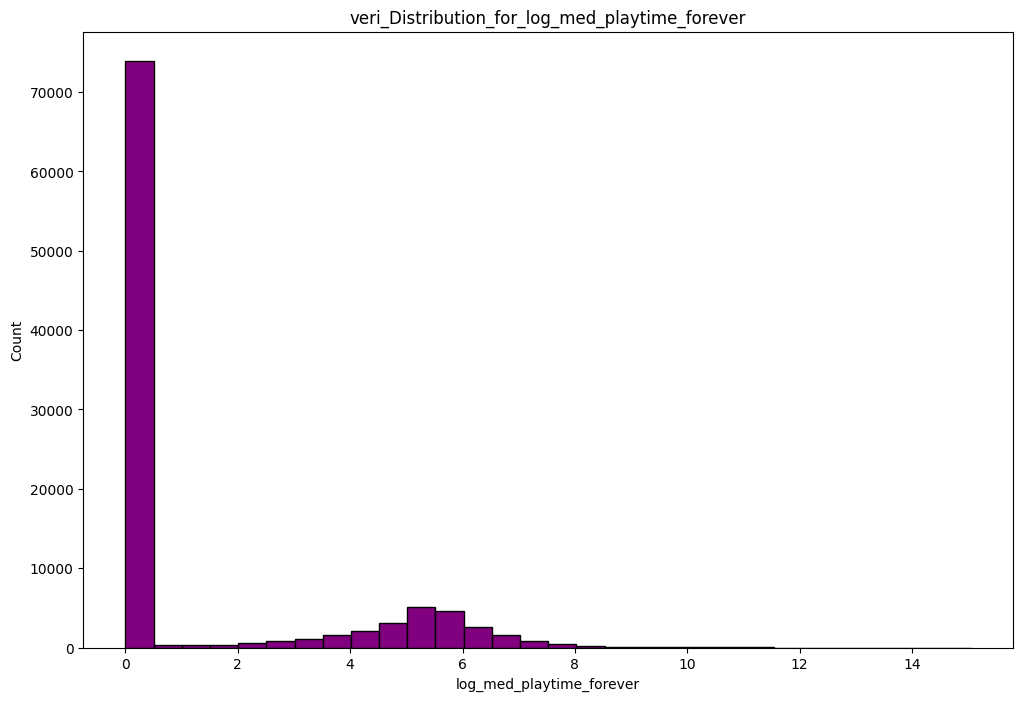

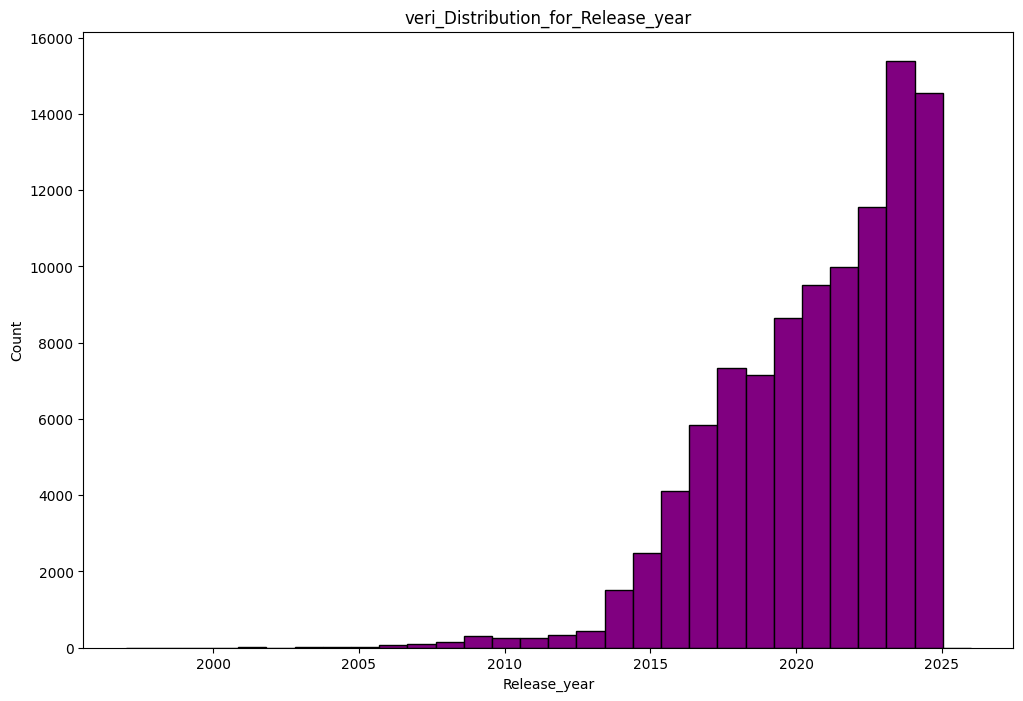

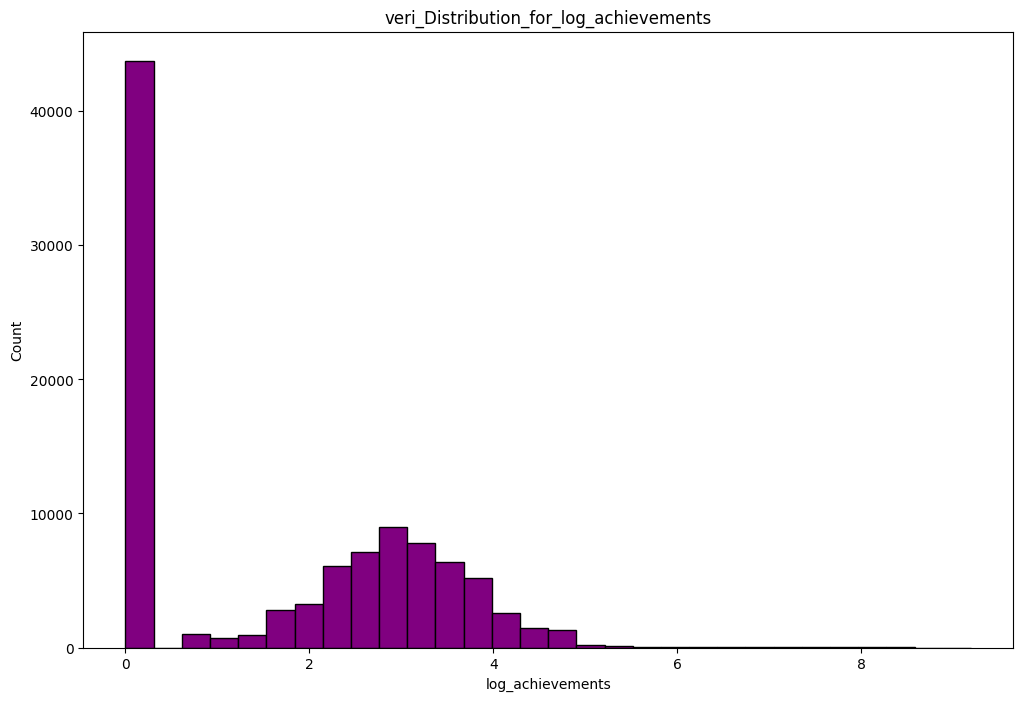

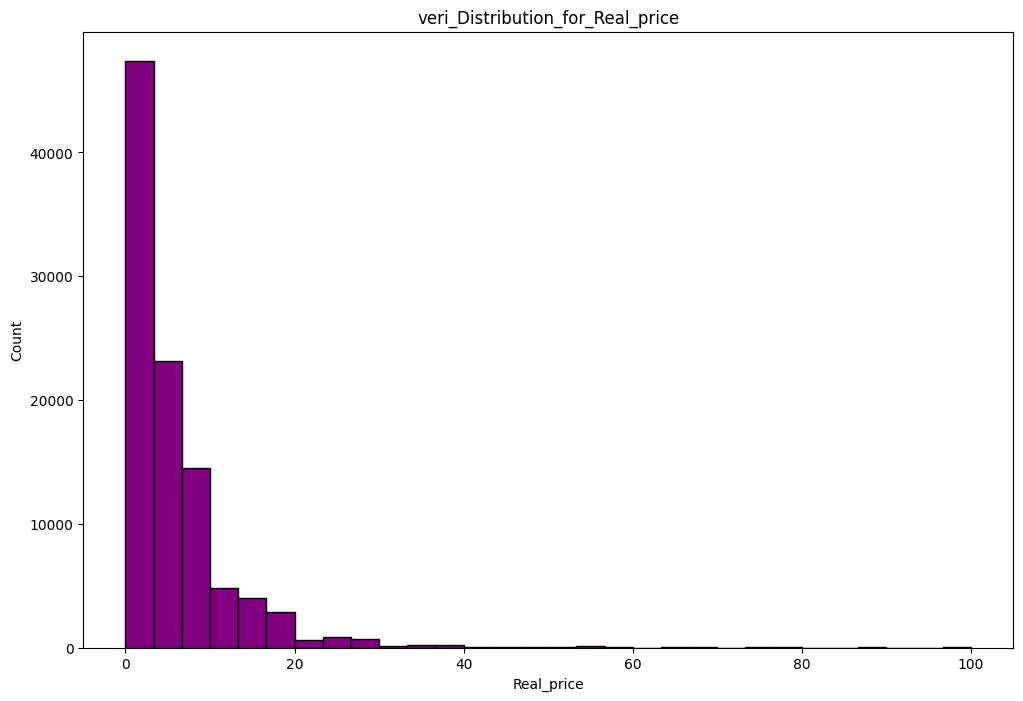

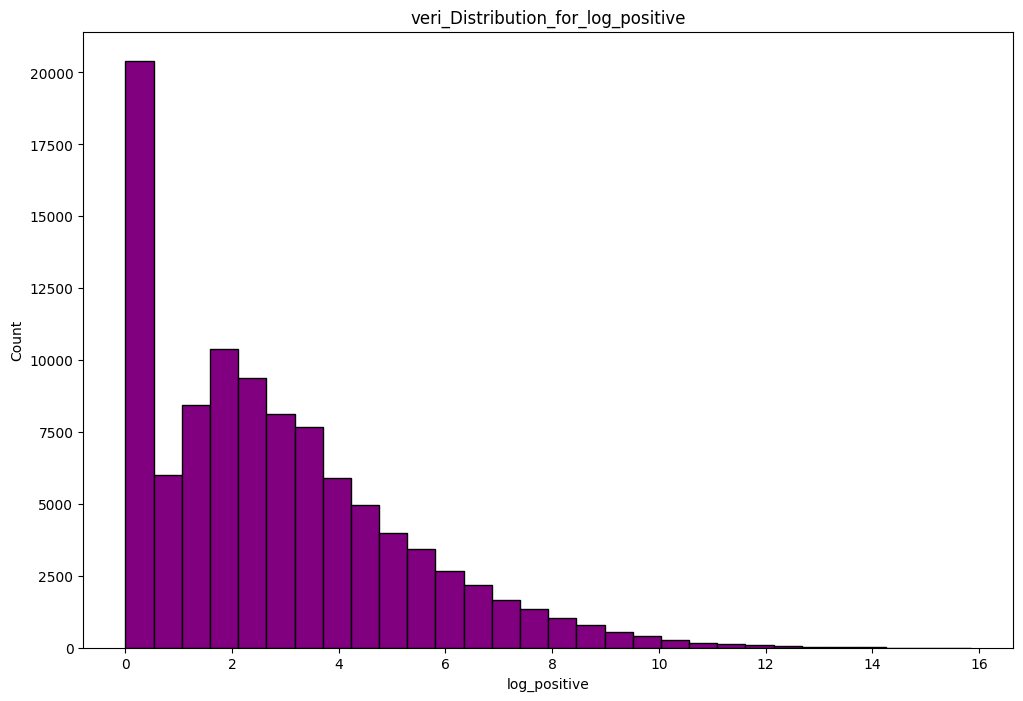

In [ ]:
for col in data[data_numcols]:
    group_hist(data, col, title = f'data_Distribution_for_{col}')

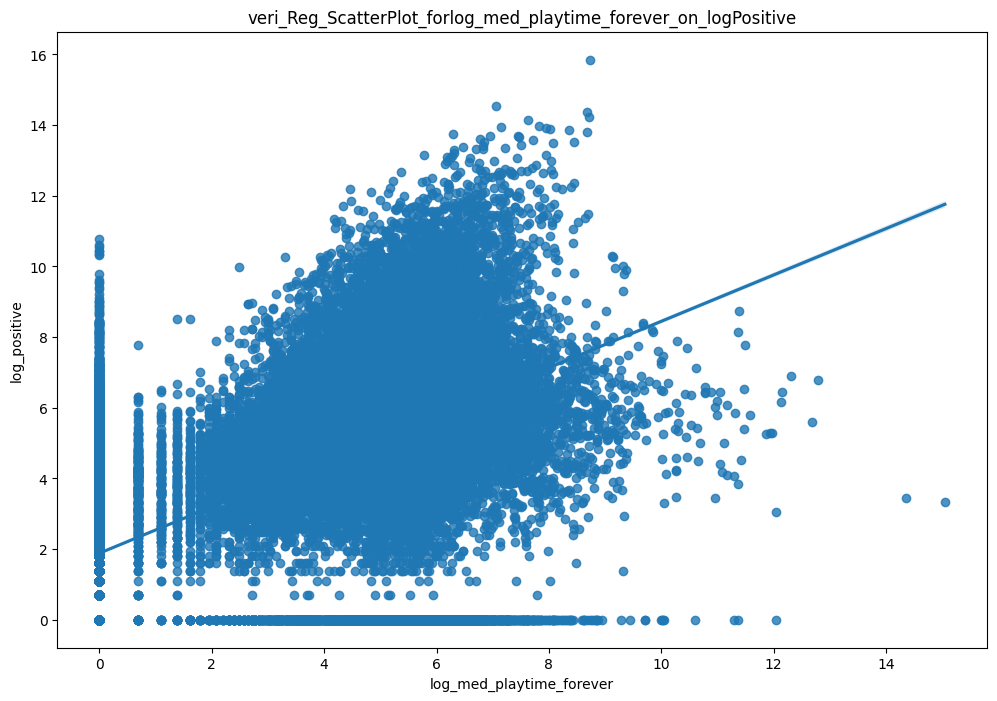

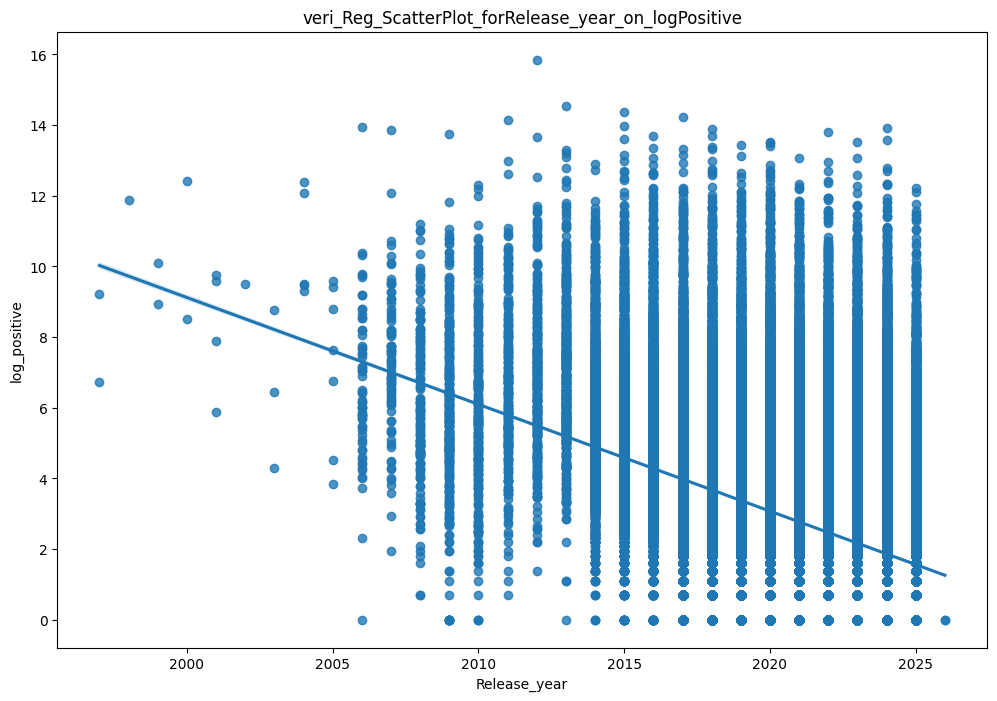

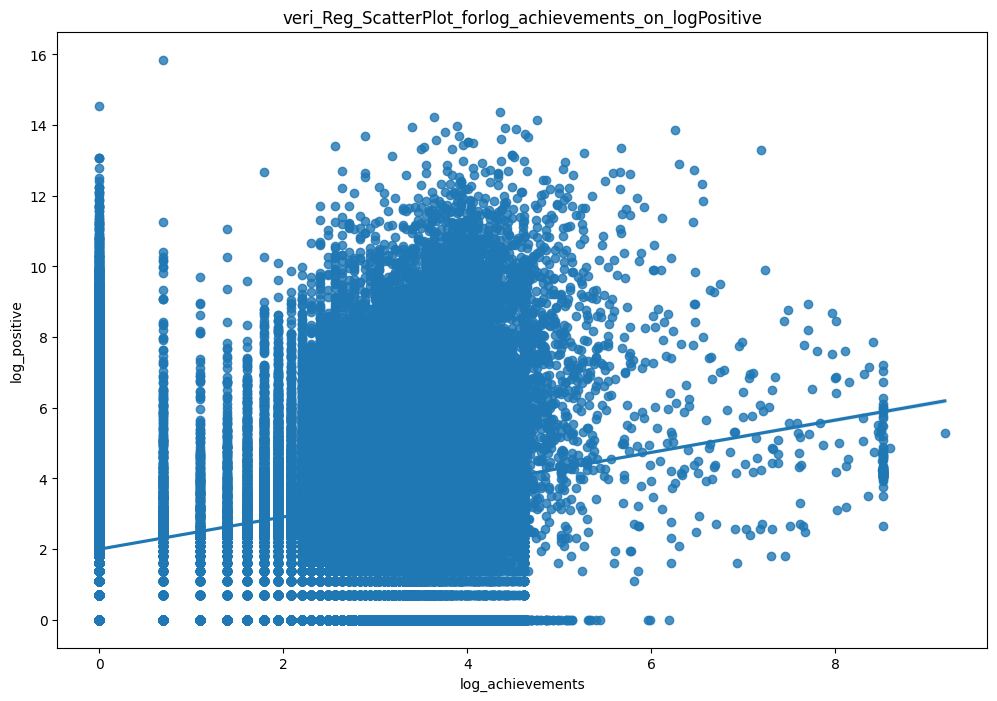

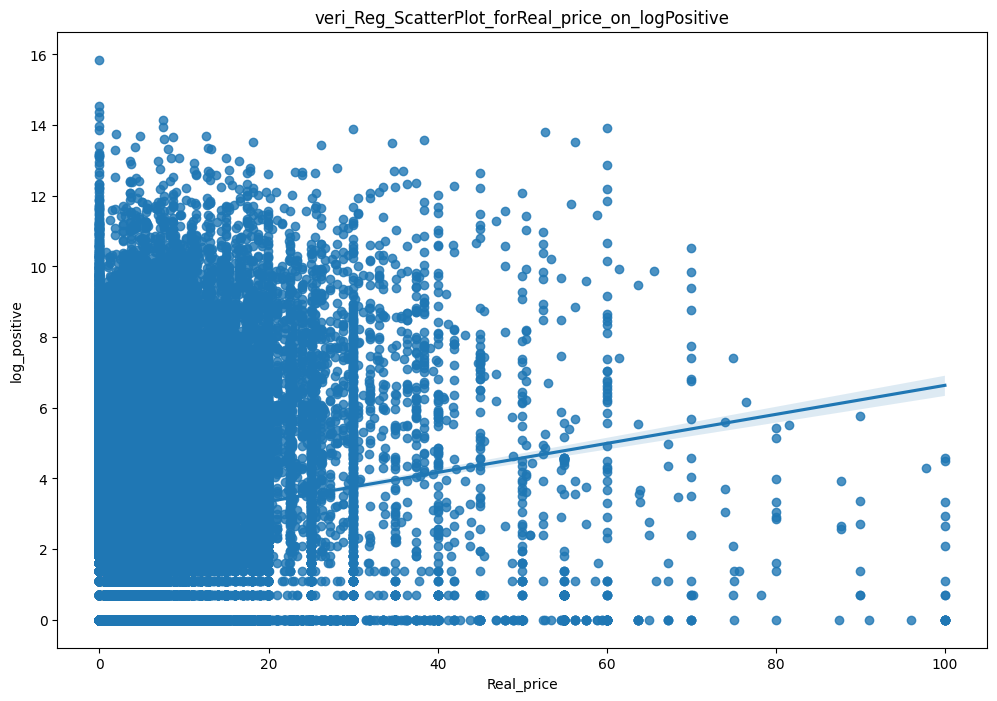

In [ ]:
for col in [col for col in data_numcols if col not in ['log_positive'] ]: 
    reg_scatter(data, title = f'data_Reg_ScatterPlot_for{col}_on_logPositive',
                x = col, y = 'log_positive' )

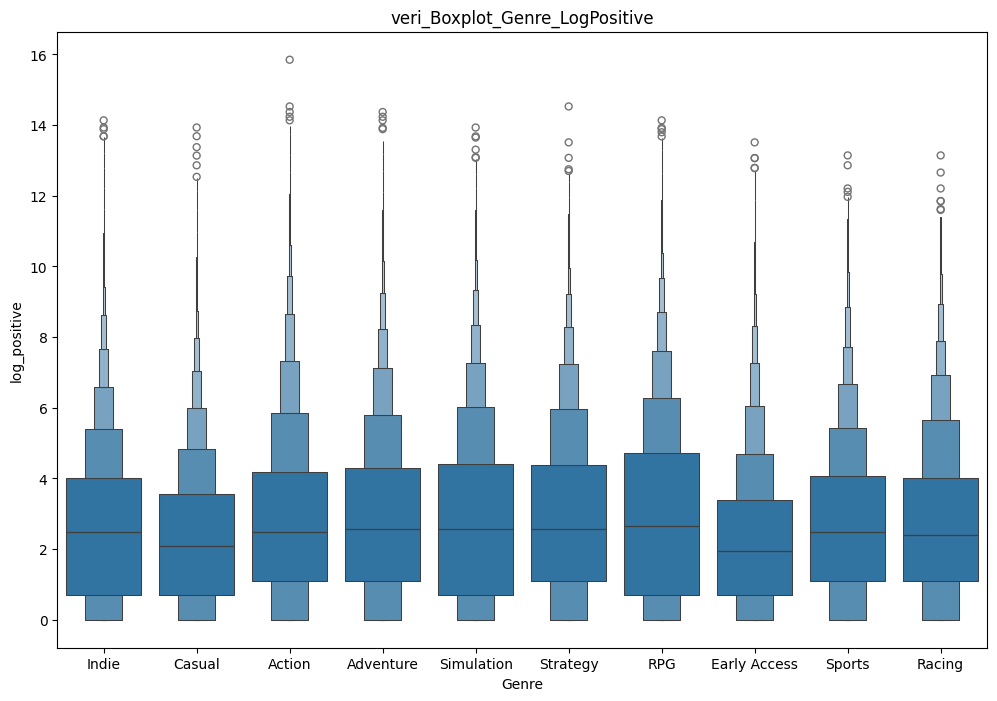

In [ ]:
# genre box plot

df_long = data.melt(
    id_vars = ['log_positive'],
    value_vars = data_catcols,
    var_name = 'Genre',
    value_name = 'Has_Genre'
)

df_long = df_long[df_long['Has_Genre'] == 1]

boxplot(df_long, x = 'Genre', y = 'log_positive', title = 'data_Boxplot_Genre_LogPositive')

## Regression Model

In [ ]:
import statsmodels.api as sm

y = data['log_positive']
X = data.copy().drop('log_positive', axis = 1)
X = sm.add_constant(X)
data_model_1 = sm.OLS(y, X).fit()

print(data_model_1.summary())

                            OLS Regression Results                            
Dep. Variable:           log_positive   R-squared:                       0.504
Model:                            OLS   Adj. R-squared:                  0.504
Method:                 Least Squares   F-statistic:                     7260.
Date:                Mon, 27 Apr 2026   Prob (F-statistic):               0.00
Time:                        10:22:46   Log-Likelihood:            -1.9320e+05
No. Observations:               99927   AIC:                         3.864e+05
Df Residuals:                   99912   BIC:                         3.866e+05
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                   